In [1]:
import pandas as pd 
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df=pd.read_csv('anime.csv')

In [3]:
df.shape

(12294, 7)

In [4]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [6]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [7]:
### missing values 
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [8]:
df['genre']=df['genre'].fillna('')
df['type'] = df['type'].fillna(0)
df['rating'] = df['rating'].fillna(0)
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.drop('anime_id', axis=1)

In [11]:
df.head()

,name,genre,type,episodes,rating,members
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [12]:
df.nunique()

name        12292
genre        3265
type            7
episodes      187
rating        599
members      6706
dtype: int64

In [13]:
df.describe()

,rating,members
count,12294.000000,1.229400e+04
mean,6.352786,1.807134e+04
std,1.343119,5.482068e+04
min,0.000000,5.000000e+00
25%,5.820000,2.250000e+02
50%,6.550000,1.550000e+03
75%,7.170000,9.437000e+03
max,10.000000,1.013917e+06


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      12294 non-null  object 
 1   genre     12294 non-null  object 
 2   type      12294 non-null  object 
 3   episodes  12294 non-null  object 
 4   rating    12294 non-null  float64
 5   members   12294 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 576.4+ KB


In [16]:
df.genre

0                     Drama, Romance, School, Supernatural
1        Action, Adventure, Drama, Fantasy, Magic, Mili...
2        Action, Comedy, Historical, Parody, Samurai, S...
3                                         Sci-Fi, Thriller
4        Action, Comedy, Historical, Parody, Samurai, S...
                               ...                        
12289                                               Hentai
12290                                               Hentai
12291                                               Hentai
12292                                               Hentai
12293                                               Hentai
Name: genre, Length: 12294, dtype: object

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')

In [19]:
tfidf1=tfidf.fit_transform(df.genre)

In [20]:
tfidf1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40418 stored elements and shape (12294, 46)>

In [23]:
similarity=cosine_similarity(tfidf1)
similarity

array([[1.        , 0.14784981, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.14784981, 1.        , 0.1786367 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.1786367 , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ]])

In [22]:
similarity.shape

(12294, 12294)

In [25]:
indices= pd.Series(data=df.index,index=df.name)
indices

name
Kimi no Na wa.                                            0
Fullmetal Alchemist: Brotherhood                          1
Gintama°                                                  2
Steins;Gate                                               3
Gintama&#039;                                             4
                                                      ...  
Toushindai My Lover: Minami tai Mecha-Minami          12289
Under World                                           12290
Violence Gekiga David no Hoshi                        12291
Violence Gekiga Shin David no Hoshi: Inma Densetsu    12292
Yasuji no Pornorama: Yacchimae!!                      12293
Length: 12294, dtype: int64

In [32]:
def recommended_anime(similar_anime,threshold=0.4):
    if similar_anime in indices.index:
        index= np.where(similar_anime==indices.index)[0][0]
        similar=sorted(list(enumerate(similarity[index])),reverse=True,key=lambda x: x[1])[1:6]
        print(f'Recommended anime of {similar_anime}')
        print('*'*30)
        for anime in similar:
            print(indices.index[anime[0]])
    else:
        print('anime is not in the list')

In [33]:
recommended_anime('Kimi no Na wa.')

Recommended anime of Kimi no Na wa.
******************************
Wind: A Breath of Heart OVA
Wind: A Breath of Heart (TV)
Aura: Maryuuin Kouga Saigo no Tatakai
Angel Beats!: Another Epilogue
Harmonie


In [53]:
def recommended_anime(similar_anime, threshold=0.5):
    if similar_anime in indices.index:
        idx = np.where(similar_anime == indices.index)[0][0]
        sim_scores = list(enumerate(similarity[idx]))
        filtered = [(i, score) for i, score in sim_scores if score >= threshold and i != idx]
        filtered = sorted(filtered, key=lambda x: x[1], reverse=True)
        if len(filtered) == 0:
            print(f"No anime found above threshold {threshold}")
            return
        
        print(f"Recommended anime for '{similar_anime}' (Threshold={threshold})")
        print('*' * 40)
        for anime_idx, score in filtered:
            print(f"{indices.index[anime_idx]} ---> Similarity Score: {score:.2f}")
    else:
        print(f"'{similar_anime}' is not in the list")


In [54]:
recommended_anime("Naruto", threshold=0.4)

Recommended anime for 'Naruto' (Threshold=0.4)
****************************************
Boruto: Naruto the Movie ---> Similarity Score: 1.00
Naruto: Shippuuden ---> Similarity Score: 1.00
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi ---> Similarity Score: 1.00
Naruto x UT ---> Similarity Score: 1.00
Naruto: Shippuuden Movie 4 - The Lost Tower ---> Similarity Score: 1.00
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono ---> Similarity Score: 1.00
Naruto Shippuuden: Sunny Side Battle ---> Similarity Score: 1.00
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!! ---> Similarity Score: 1.00
Kyutai Panic Adventure! ---> Similarity Score: 0.98
Naruto: Shippuuden Movie 6 - Road to Ninja ---> Similarity Score: 0.95
Rekka no Honoo ---> Similarity Score: 0.95
Naruto: Honoo no Chuunin Shiken! Naruto vs. Konohamaru!! ---> Similarity Score: 0.95
Street Fighter Zero The Animation ---> Similarity Score: 0.94
Dragon Ball Z ---> Similarity Score: 0.94
Dragon Ball 

In [55]:
recommended_anime("Naruto", threshold=0.5)

Recommended anime for 'Naruto' (Threshold=0.5)
****************************************
Boruto: Naruto the Movie ---> Similarity Score: 1.00
Naruto: Shippuuden ---> Similarity Score: 1.00
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi ---> Similarity Score: 1.00
Naruto x UT ---> Similarity Score: 1.00
Naruto: Shippuuden Movie 4 - The Lost Tower ---> Similarity Score: 1.00
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono ---> Similarity Score: 1.00
Naruto Shippuuden: Sunny Side Battle ---> Similarity Score: 1.00
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!! ---> Similarity Score: 1.00
Kyutai Panic Adventure! ---> Similarity Score: 0.98
Naruto: Shippuuden Movie 6 - Road to Ninja ---> Similarity Score: 0.95
Rekka no Honoo ---> Similarity Score: 0.95
Naruto: Honoo no Chuunin Shiken! Naruto vs. Konohamaru!! ---> Similarity Score: 0.95
Street Fighter Zero The Animation ---> Similarity Score: 0.94
Dragon Ball Z ---> Similarity Score: 0.94
Dragon Ball 

In [56]:
target = "Naruto"
recs = recommended_anime(target, threshold=0.4)


Recommended anime for 'Naruto' (Threshold=0.4)
****************************************
Boruto: Naruto the Movie ---> Similarity Score: 1.00
Naruto: Shippuuden ---> Similarity Score: 1.00
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi ---> Similarity Score: 1.00
Naruto x UT ---> Similarity Score: 1.00
Naruto: Shippuuden Movie 4 - The Lost Tower ---> Similarity Score: 1.00
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono ---> Similarity Score: 1.00
Naruto Shippuuden: Sunny Side Battle ---> Similarity Score: 1.00
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!! ---> Similarity Score: 1.00
Kyutai Panic Adventure! ---> Similarity Score: 0.98
Naruto: Shippuuden Movie 6 - Road to Ninja ---> Similarity Score: 0.95
Rekka no Honoo ---> Similarity Score: 0.95
Naruto: Honoo no Chuunin Shiken! Naruto vs. Konohamaru!! ---> Similarity Score: 0.95
Street Fighter Zero The Animation ---> Similarity Score: 0.94
Dragon Ball Z ---> Similarity Score: 0.94
Dragon Ball 

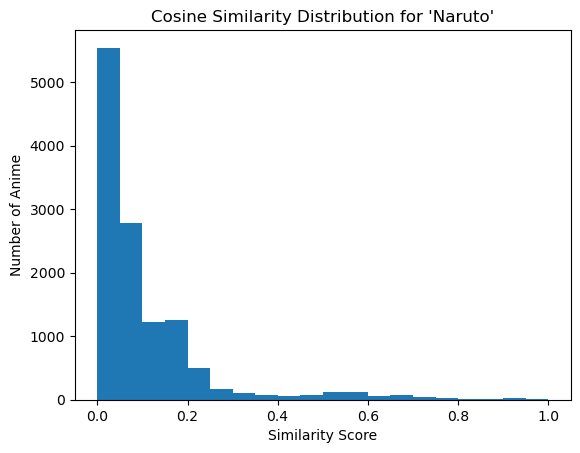

In [57]:
import matplotlib.pyplot as plt
import numpy as np

idx = np.where(target == indices.index)[0][0]
scores = similarity[idx]

plt.hist(scores, bins=20)
plt.title(f"Cosine Similarity Distribution for '{target}'")
plt.xlabel("Similarity Score")
plt.ylabel("Number of Anime")
plt.show()


In [60]:
### if threshold is 0.2 -- 	Many recommendations (low similarity)
### if threshold is 0.4 -- 	Moderate no of recommendations
### if threshold is 0.6	-- Few	no of recommendations
### if threshold is 0.8	-- 1-2	 recommendations

In [61]:
### 1. User-based CF recommends items liked by similar users, while item-based CF recommends items similar to those you already liked.
### 2.Collaborative Filtering is a recommendation technique that predicts a user’s interest in an item based on the preferences of other users or similar items.